# 🏥 Đánh Giá Model Phát Hiện Bệnh Da Liễu
**Skin Disease Detection — Business Evaluation Report**

> Model: Faster R-CNN + ResNet-50 FPN  
> Dataset: ISIC Skin Lesion — 9 classes  
> Metrics: mAP@0.5, mAP@0.5:0.95, Precision, Recall  
> Qualitative: GT vs Prediction visualization

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.notebook import tqdm

# ─── CONFIG ───────────────────────────────────────────────────────
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = r'../../checkpoints/best.pth'
TEST_DIR   = r'../data/test'
CONF_THRESH = 0.3   # ngưỡng confidence khi hiển thị
BATCH_SIZE  = 4
N_QUALITATIVE = 8  # số ảnh so sánh GT vs Pred

CLASSES = [
    'nevus', 'melanoma', 'seborrheic keratosis',
    'pigmented benign keratosis', 'vascular lesion',
    'basal cell carcinoma', 'squamous cell carcinoma',
    'dermatofibroma', 'actinic keratosis'
]
NUM_CLASSES = len(CLASSES) + 1  # +1 background

PALETTE = plt.cm.get_cmap('tab10', len(CLASSES))
COLOR   = {cls: tuple((np.array(PALETTE(i)[:3]) * 255).astype(int).tolist()) for i, cls in enumerate(CLASSES)}

transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["labels"],
        min_visibility=0.1
    )
)

print(f'Device : {DEVICE}')
print(f'Classes: {len(CLASSES)}')
print(f'Test   : {TEST_DIR}')


Device : cuda
Classes: 9
Test   : ../data/test


## 1. Dataset & DataLoader

In [2]:
class SkinTestDataset(Dataset):
    LABEL_MAP = {cls: i+1 for i, cls in enumerate(CLASSES)}
    LABEL_MAP['background'] = 0

    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        self.imgs = sorted([f for f in os.listdir(root)
                            if f.lower().endswith(('.jpg','.jpeg','.png'))])

    def _parse_xml(self, xml_path):
        boxes, labels = [], []
        tree = ET.parse(xml_path)
        for obj in tree.getroot().findall('object'):
            name = obj.find('name').text
            if name not in self.LABEL_MAP:
                continue
            bb = obj.find('bndbox')
            x1, y1 = float(bb.find('xmin').text), float(bb.find('ymin').text)
            x2, y2 = float(bb.find('xmax').text), float(bb.find('ymax').text)
            if x2 > x1 and y2 > y1:
                boxes.append([x1, y1, x2, y2])
                labels.append(self.LABEL_MAP[name])
        return boxes, labels

    def __getitem__(self, idx):
        name   = self.imgs[idx]
        img    = cv2.cvtColor(cv2.imread(os.path.join(self.root, name)), cv2.COLOR_BGR2RGB)
        xml    = os.path.join(self.root, os.path.splitext(name)[0] + '.xml')
        boxes, labels = self._parse_xml(xml)

        if self.transforms:
            out    = self.transforms(image=img, bboxes=boxes, labels=labels)
            img    = out['image']
            boxes  = out['bboxes']
            labels = out['labels']

        img_t  = img if isinstance(img, torch.Tensor) else torch.from_numpy(img).permute(2,0,1).float()/255.
        img_t  = img_t.float()
        target = {
            'boxes' : torch.as_tensor(boxes,  dtype=torch.float32).reshape(-1,4),
            'labels': torch.as_tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([idx]),
            'img_name': name
        }
        return img_t, target

    def __len__(self): return len(self.imgs)

def collate_fn(batch): return tuple(zip(*batch))

dataset = SkinTestDataset(TEST_DIR, transform)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=0, collate_fn=collate_fn)
print(f'Test set: {len(dataset)} images, {len(loader)} batches')


Test set: 100 images, 25 batches


## 2. Load Model

In [3]:
model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
in_ch = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_ch, NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE).eval()
print('Model loaded successfully ✓')
total = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total:,}')


Model loaded successfully ✓
Parameters: 41,340,161


## 3. Inference trên toàn bộ Test Set

In [4]:
all_preds, all_gts, all_outputs, all_imgs = [], [], [], []

with torch.no_grad():
    for imgs, targets in tqdm(loader, desc='Evaluating'):
        imgs_dev = [i.to(DEVICE) for i in imgs]
        outs     = model(imgs_dev)

        for img_t, out, tgt in zip(imgs, outs, targets):
            all_preds.append({
                'boxes' : out['boxes'].cpu(),
                'scores': out['scores'].cpu(),
                'labels': out['labels'].cpu()
            })
            all_gts.append({
                'boxes' : tgt['boxes'].cpu(),
                'labels': tgt['labels'].cpu()
            })
            all_outputs.append({'out': out, 'tgt': tgt})
            all_imgs.append(img_t.cpu())

print(f'Inference complete. {len(all_preds)} images processed.')


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Inference complete. 100 images processed.


## 4. Kết Quả Định Lượng (Quantitative Metrics)
### 4.1 mAP (Mean Average Precision)

In [5]:
metric = MeanAveragePrecision(iou_type='bbox', class_metrics=True)
metric.update(all_preds, all_gts)
results = metric.compute()

map_all  = results['map'].item()
map_50   = results['map_50'].item()
map_75   = results['map_75'].item()
mar_100  = results['mar_100'].item()

print('='*55)
print(f"{'EVALUATION REPORT':^55}")
print('='*55)
print(f"  mAP  (IoU 0.50:0.95) : {map_all:>8.4f}")
print(f"  mAP  (IoU 0.50)      : {map_50:>8.4f}")
print(f"  mAP  (IoU 0.75)      : {map_75:>8.4f}")
print(f"  mAR  (max 100 det)   : {mar_100:>8.4f}")
print('-'*55)
print(f"{'CLASS':25s} {'mAP':>8}  {'mAR':>8}")
print('-'*55)
map_pc = results.get('map_per_class', [])
mar_pc = results.get('mar_100_per_class', [])
for i, cls in enumerate(CLASSES):
    m = map_pc[i].item() if i < len(map_pc) else -1
    r = mar_pc[i].item() if i < len(mar_pc) else -1
    ms = f"{m:.4f}" if m != -1 else '  N/A  '
    rs = f"{r:.4f}" if r != -1 else '  N/A  '
    print(f"  {cls:23s} {ms:>8}  {rs:>8}")
print('='*55)


                   EVALUATION REPORT                   
  mAP  (IoU 0.50:0.95) :   0.0042
  mAP  (IoU 0.50)      :   0.0147
  mAP  (IoU 0.75)      :   0.0007
  mAR  (max 100 det)   :   0.1389
-------------------------------------------------------
CLASS                          mAP       mAR
-------------------------------------------------------
  nevus                     0.0000    0.0000
  melanoma                  0.0051    0.1250
  seborrheic keratosis      0.0012    0.0500
  pigmented benign keratosis   0.0097    0.2000
  vascular lesion           0.0023    0.1200
  basal cell carcinoma      0.0021    0.2071
  squamous cell carcinoma   0.0098    0.2000
  dermatofibroma            0.0072    0.1182
  actinic keratosis         0.0007    0.2300


### 4.2 Biểu đồ mAP theo từng class

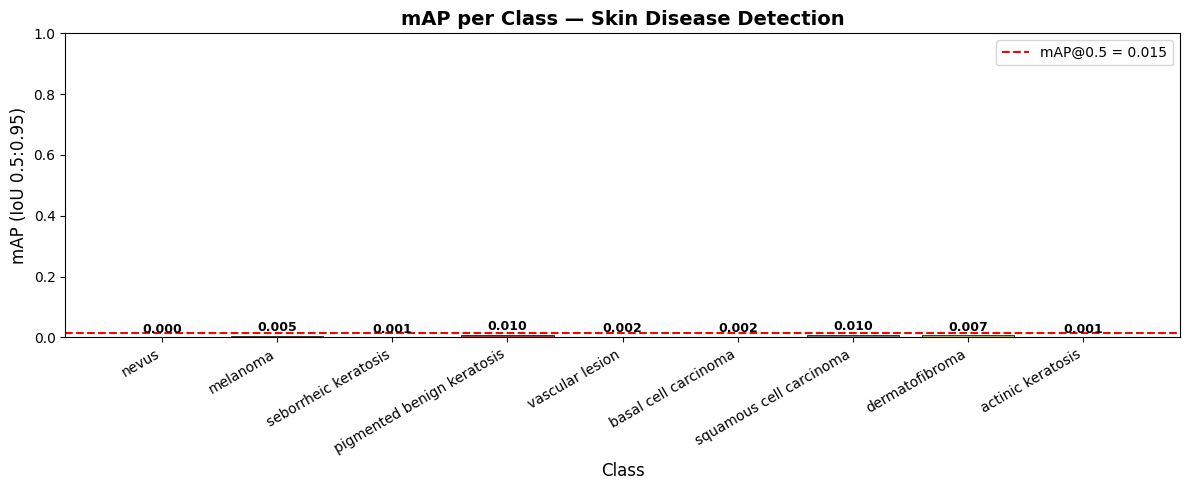

Chart saved: mAP_per_class.png


In [6]:
map_pc  = results.get('map_per_class', [])
vals    = [map_pc[i].item() if i < len(map_pc) and map_pc[i] != -1 else 0 for i in range(len(CLASSES))]
colors  = [PALETTE(i) for i in range(len(CLASSES))]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(CLASSES, vals, color=colors, edgecolor='black', linewidth=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(map_50, color='red', linewidth=1.5, linestyle='--', label=f'mAP@0.5 = {map_50:.3f}')
ax.set_ylim(0, 1.0)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('mAP (IoU 0.5:0.95)', fontsize=12)
ax.set_title('mAP per Class — Skin Disease Detection', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('mAP_per_class.png', dpi=150)
plt.show()
print('Chart saved: mAP_per_class.png')


### 4.3 Precision & Recall (IoU@0.5, conf ≥ threshold)

In [7]:
def compute_pr(preds, gts, iou_thresh=0.5, score_thresh=CONF_THRESH):
    tp = fp = fn = 0
    for pred, gt in zip(preds, gts):
        pb = pred['boxes'][pred['scores'] >= score_thresh]
        pl = pred['labels'][pred['scores'] >= score_thresh]
        gb, gl = gt['boxes'], gt['labels']
        matched = set()
        for b, l in zip(pb, pl):
            best_iou, best_j = 0, -1
            for j, (gb_j, gl_j) in enumerate(zip(gb, gl)):
                if j in matched or gl_j != l: continue
                ix1 = max(b[0], gb_j[0]); iy1 = max(b[1], gb_j[1])
                ix2 = min(b[2], gb_j[2]); iy2 = min(b[3], gb_j[3])
                inter = max(0, ix2-ix1) * max(0, iy2-iy1)
                union = (b[2]-b[0])*(b[3]-b[1]) + (gb_j[2]-gb_j[0])*(gb_j[3]-gb_j[1]) - inter
                iou   = inter/union if union > 0 else 0
                if iou > best_iou: best_iou, best_j = iou, j
            if best_iou >= iou_thresh:
                tp += 1; matched.add(best_j)
            else:
                fp += 1
        fn += len(gb) - len(matched)
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0
    rec  = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    return prec, rec, f1, tp, fp, fn

prec, rec, f1, tp, fp, fn = compute_pr(all_preds, all_gts)
print(f'Threshold conf >= {CONF_THRESH}, IoU >= 0.5')
print(f'  TP={tp}  FP={fp}  FN={fn}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')


Threshold conf >= 0.3, IoU >= 0.5
  TP=4  FP=1279  FN=98
  Precision : 0.0031
  Recall    : 0.0392
  F1-Score  : 0.0058


### 4.4 Tổng hợp Precision / Recall / F1 theo ngưỡng confidence

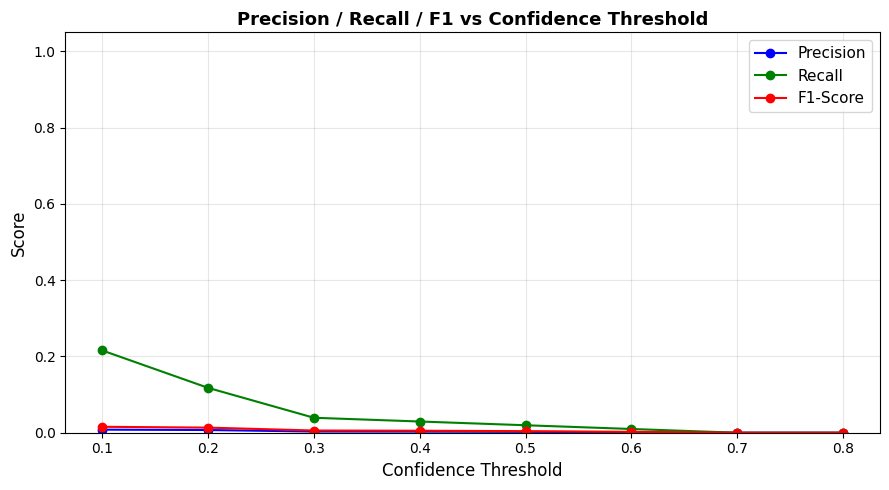

Chart saved: pr_curve.png


In [8]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
precs, recs, f1s = [], [], []
for t in thresholds:
    p, r, f, *_ = compute_pr(all_preds, all_gts, score_thresh=t)
    precs.append(p); recs.append(r); f1s.append(f)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precs, 'b-o', label='Precision')
ax.plot(thresholds, recs,  'g-o', label='Recall')
ax.plot(thresholds, f1s,   'r-o', label='F1-Score')
ax.set_xlabel('Confidence Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision / Recall / F1 vs Confidence Threshold', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()
print('Chart saved: pr_curve.png')


## 5. Kết Quả Định Tính (Qualitative Results)
### 5.1 So sánh Ground Truth và Prediction

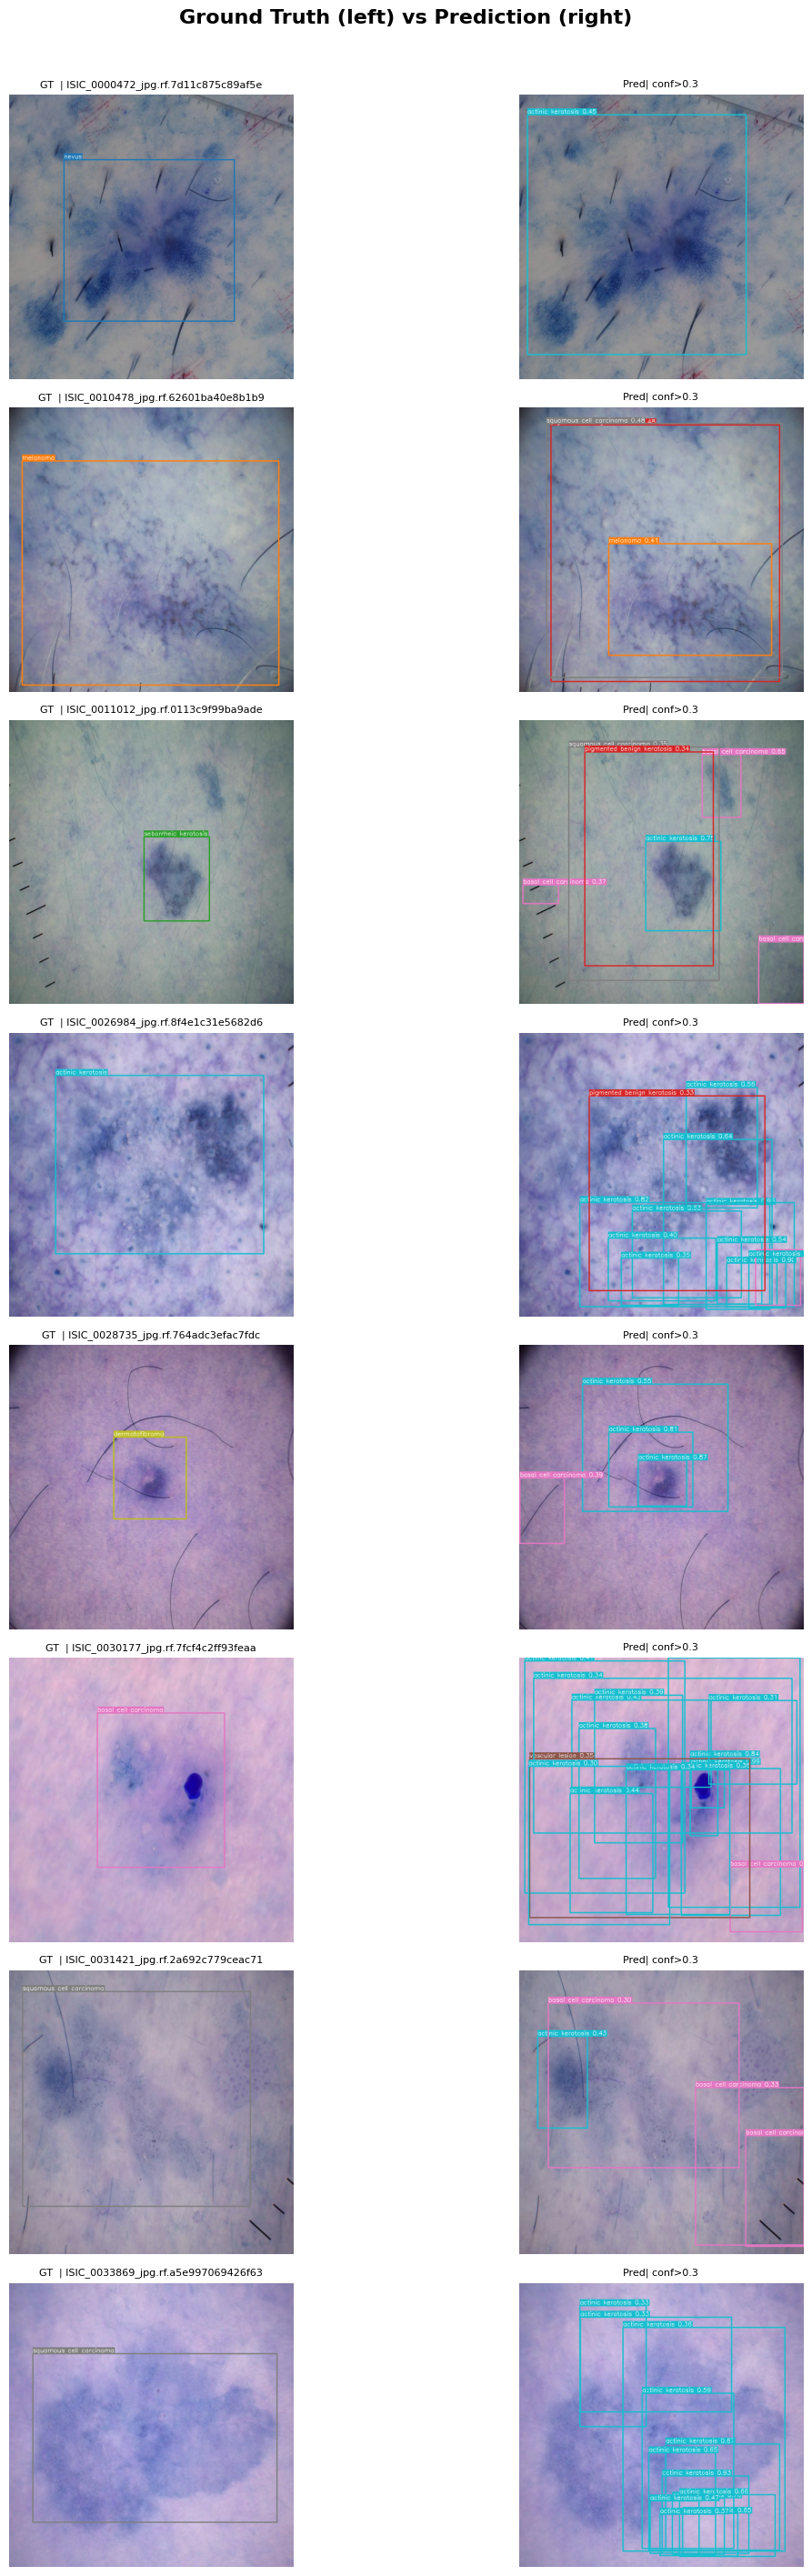

Saved: gt_vs_pred.png


In [9]:
def tensor_to_bgr(img_t):
    """Denormalize ImageNet tensor -> uint8 HWC BGR"""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img_t.permute(1,2,0).numpy()
    img  = (img * std + mean).clip(0,1)
    return (img * 255).astype(np.uint8)

def draw_boxes(img_np, boxes, labels, scores=None, color_map=COLOR):
    out = img_np.copy()
    for i, (b, l) in enumerate(zip(boxes, labels)):
        cls   = CLASSES[l-1] if 1<=l<=len(CLASSES) else 'bg'
        col   = color_map.get(cls, (0,255,0))[::-1]  # RGB -> BGR for cv2
        x1,y1,x2,y2 = b.int().tolist()
        cv2.rectangle(out, (x1,y1), (x2,y2), col, 2)
        score_txt = f" {scores[i]:.2f}" if scores is not None else ''
        label_txt = f"{cls}{score_txt}"
        (tw, th), _ = cv2.getTextSize(label_txt, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(out, (x1, y1-th-4), (x1+tw, y1), col, -1)
        cv2.putText(out, label_txt, (x1, y1-3), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 1)
    return out

indices = np.linspace(0, len(all_imgs)-1, N_QUALITATIVE, dtype=int)

fig, axes = plt.subplots(N_QUALITATIVE, 2, figsize=(14, N_QUALITATIVE*3.5))
fig.suptitle('Ground Truth (left) vs Prediction (right)', fontsize=16, fontweight='bold', y=1.01)

for row, idx in enumerate(indices):
    img_np = tensor_to_bgr(all_imgs[idx])

    gt  = all_gts[idx]
    pr  = all_preds[idx]
    mask = pr['scores'] >= CONF_THRESH

    gt_img   = draw_boxes(img_np, gt['boxes'],          gt['labels'])
    pred_img = draw_boxes(img_np, pr['boxes'][mask],    pr['labels'][mask], pr['scores'][mask])

    fname = dataset.imgs[idx]
    axes[row,0].imshow(cv2.cvtColor(gt_img,   cv2.COLOR_BGR2RGB)); axes[row,0].set_title(f'GT  | {fname[:35]}', fontsize=8); axes[row,0].axis('off')
    axes[row,1].imshow(cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)); axes[row,1].set_title(f'Pred| conf>{CONF_THRESH}', fontsize=8); axes[row,1].axis('off')

plt.tight_layout()
plt.savefig('gt_vs_pred.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: gt_vs_pred.png')


### 5.2 Phân phối điểm Confidence của toàn bộ Prediction

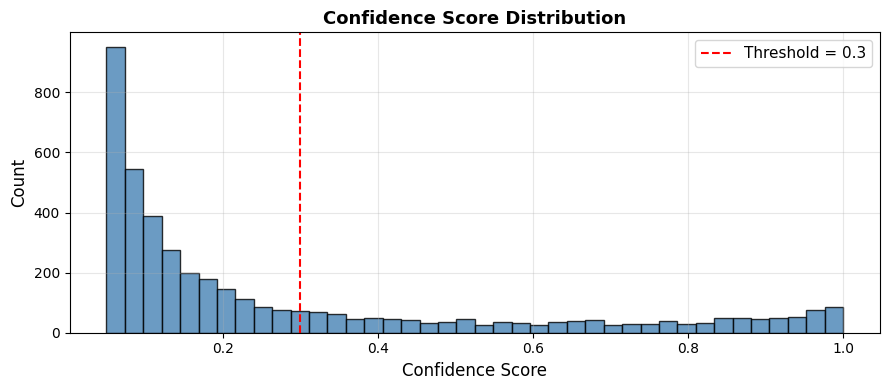

Total predictions: 4277  |  Above threshold: 1283


In [10]:
all_scores = torch.cat([p['scores'] for p in all_preds]).numpy()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_scores, bins=40, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(CONF_THRESH, color='red', linestyle='--', label=f'Threshold = {CONF_THRESH}')
ax.set_xlabel('Confidence Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Confidence Score Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('conf_dist.png', dpi=150)
plt.show()
print(f'Total predictions: {len(all_scores)}  |  Above threshold: {(all_scores>=CONF_THRESH).sum()}')


## 6. Tổng Kết (Executive Summary)

### 10. Phân Rã Lỗi Chi Tiết (Detailed FP Breakdown)


--- Breakdown of False Positives ---
Localization Errors (Lỗi định vị) : 35
Classification Errors (Lỗi phân loại): 687
Background Errors (Lỗi bối cảnh)   : 557


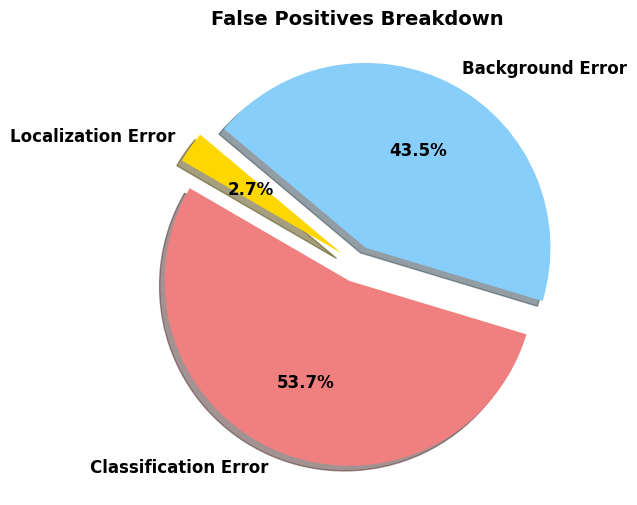

Chart saved: fp_breakdown.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_detailed_fp(preds, gts, iou_thresh=0.5, score_thresh=CONF_THRESH):
    loc_err = 0
    cls_err = 0
    bg_err = 0
    
    for pred, gt in zip(preds, gts):
        pb = pred['boxes'][pred['scores'] >= score_thresh]
        pl = pred['labels'][pred['scores'] >= score_thresh]
        gb, gl = gt['boxes'], gt['labels']
        
        for b, l in zip(pb, pl):
            best_iou = 0
            best_j = -1
            for j, (gb_j, gl_j) in enumerate(zip(gb, gl)):
                ix1 = max(b[0].item(), gb_j[0].item()); iy1 = max(b[1].item(), gb_j[1].item())
                ix2 = min(b[2].item(), gb_j[2].item()); iy2 = min(b[3].item(), gb_j[3].item())
                inter = max(0, ix2-ix1) * max(0, iy2-iy1)
                union = (b[2].item()-b[0].item())*(b[3].item()-b[1].item()) + (gb_j[2].item()-gb_j[0].item())*(gb_j[3].item()-gb_j[1].item()) - inter
                iou = inter/union if union > 0 else 0
                if iou > best_iou:
                    best_iou = iou
                    best_j = j
            
            if best_iou >= iou_thresh:
                if gl[best_j] != l:
                    cls_err += 1 # Classification Error
                # if gl[best_j] == l, it's TP, not FP
            elif 0.1 <= best_iou < iou_thresh:
                if best_j != -1 and gl[best_j] == l:
                    loc_err += 1 # Localization Error
                else:
                    cls_err += 1 # Classification Error
            else:
                bg_err += 1 # Background Error
                
    return loc_err, cls_err, bg_err

loc_err, cls_err, bg_err = analyze_detailed_fp(all_preds, all_gts)
print(f"--- Breakdown of False Positives ---")
print(f"Localization Errors (Lỗi định vị) : {loc_err}")
print(f"Classification Errors (Lỗi phân loại): {cls_err}")
print(f"Background Errors (Lỗi bối cảnh)   : {bg_err}")

# Pie chart
labels = ['Localization Error', 'Classification Error', 'Background Error']
sizes = [loc_err, cls_err, bg_err]
colors = ['gold', 'lightcoral', 'lightskyblue']
explode = (0.1, 0.1, 0.1)

if sum(sizes) > 0:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=140, textprops={'fontsize': 12, 'fontweight': 'bold'})
    ax.set_title('False Positives Breakdown', fontsize=14, fontweight='bold')
    plt.savefig('fp_breakdown.png', dpi=150)
    plt.show()
    print('Chart saved: fp_breakdown.png')


### 11. Phân Tích Trực Quan (Top 10 TPs, Worst FPs, FNs)


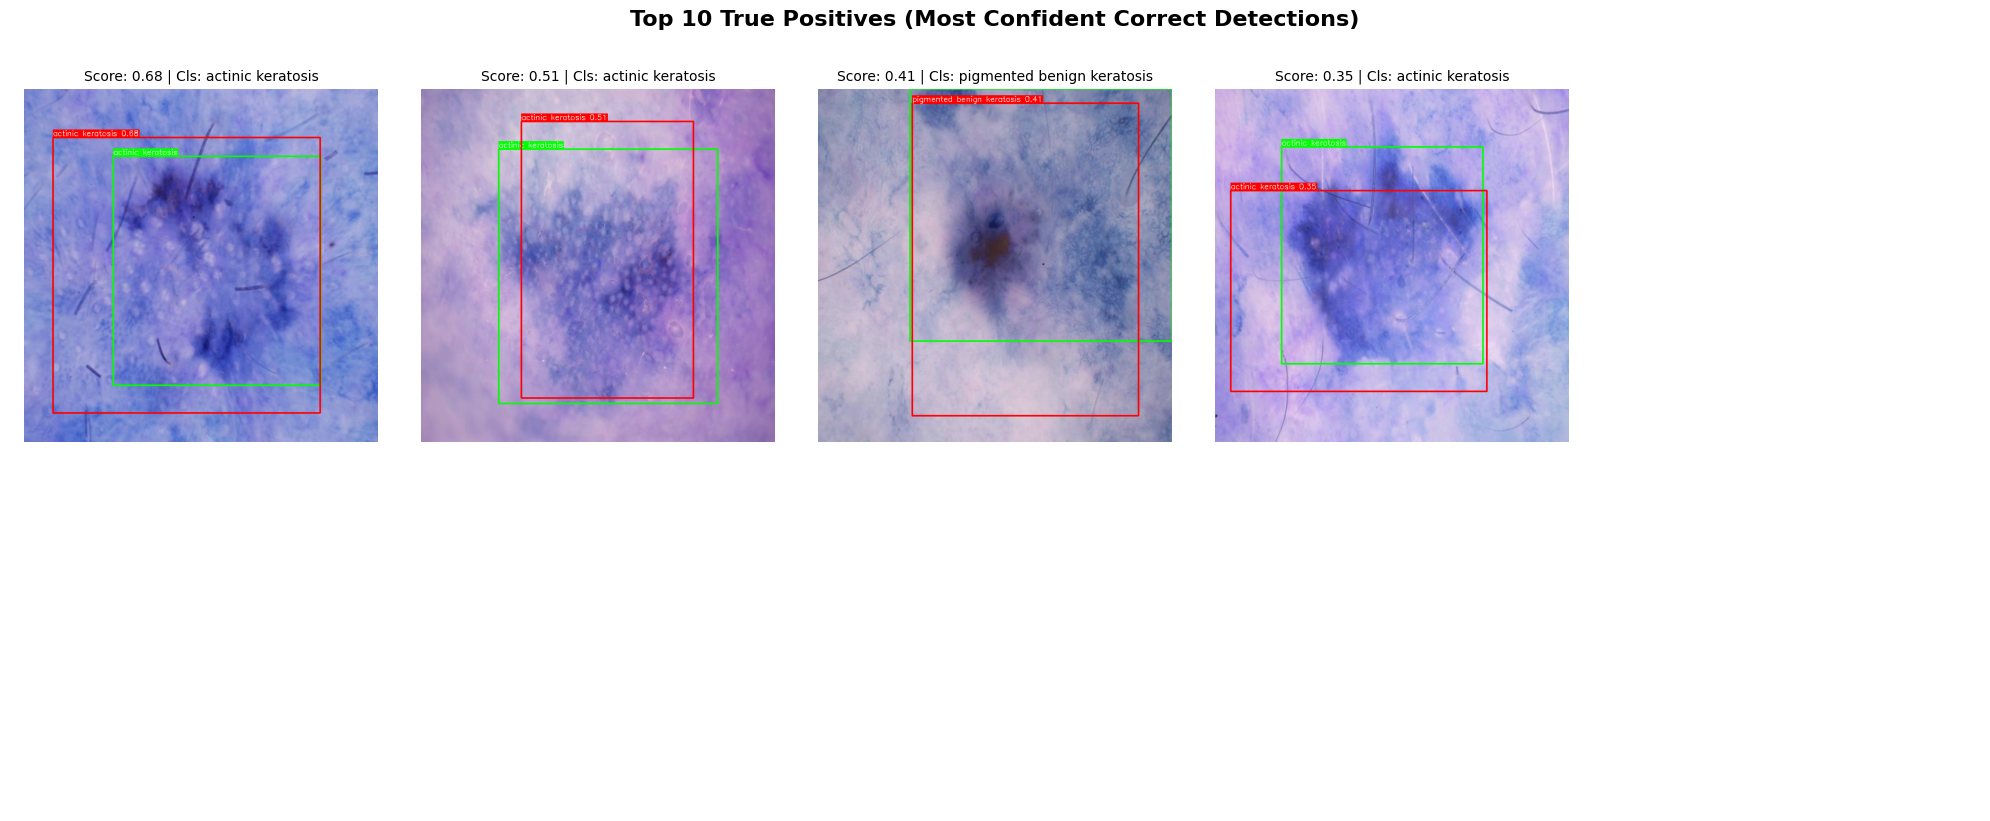

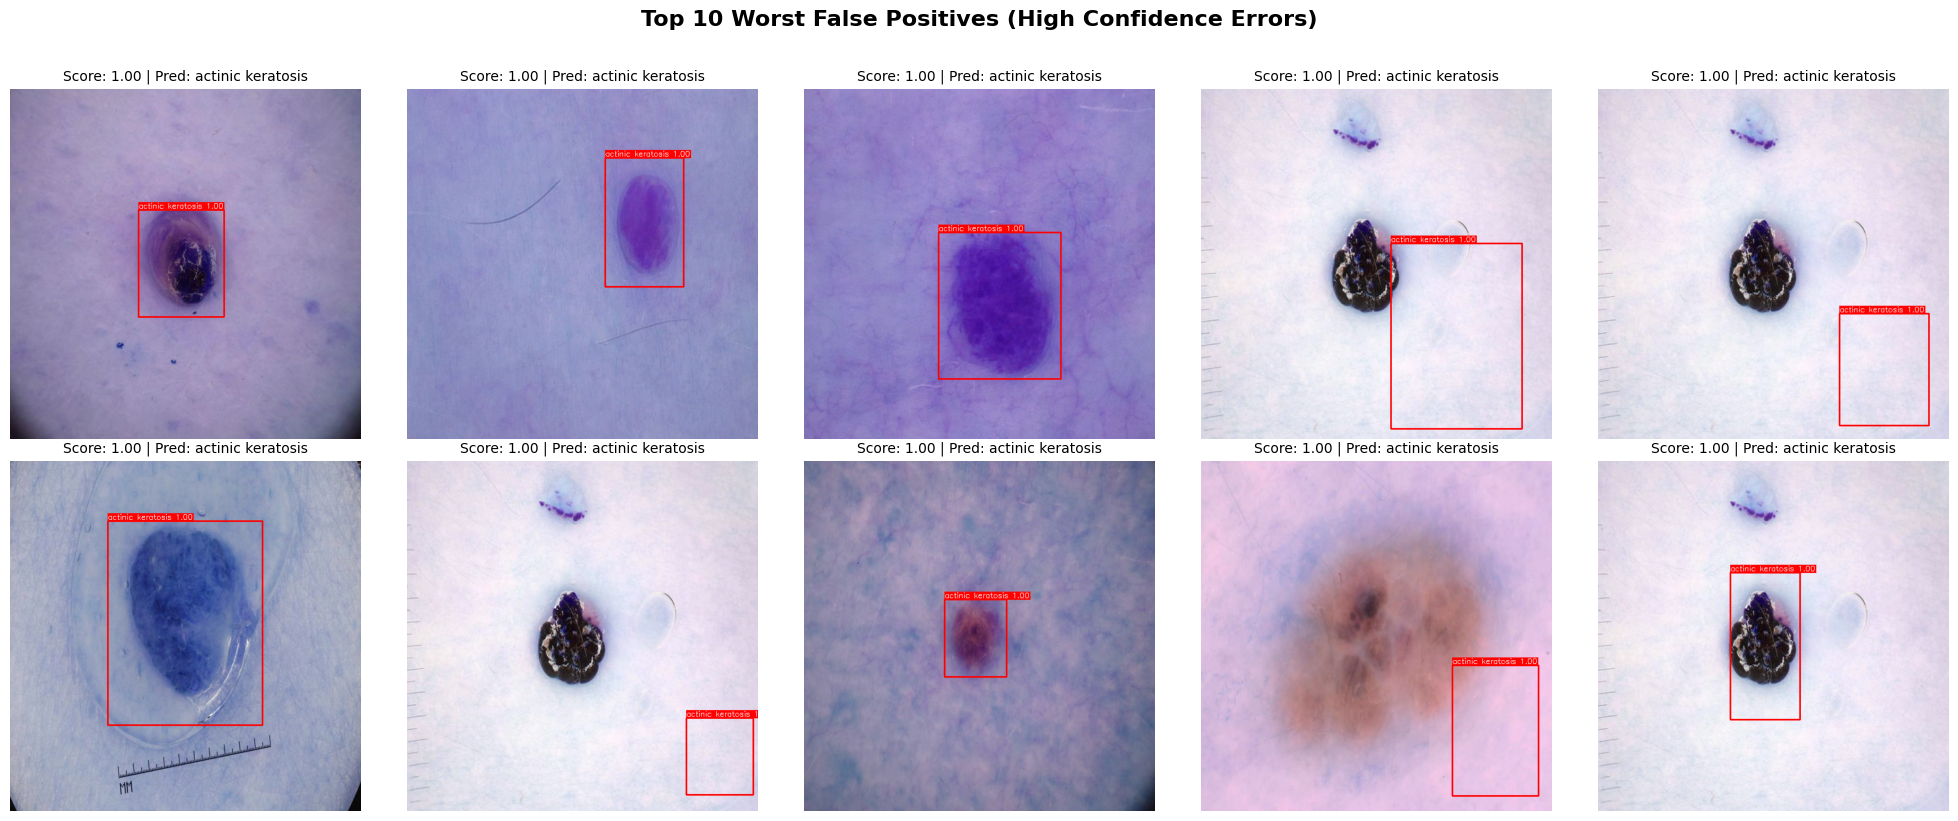

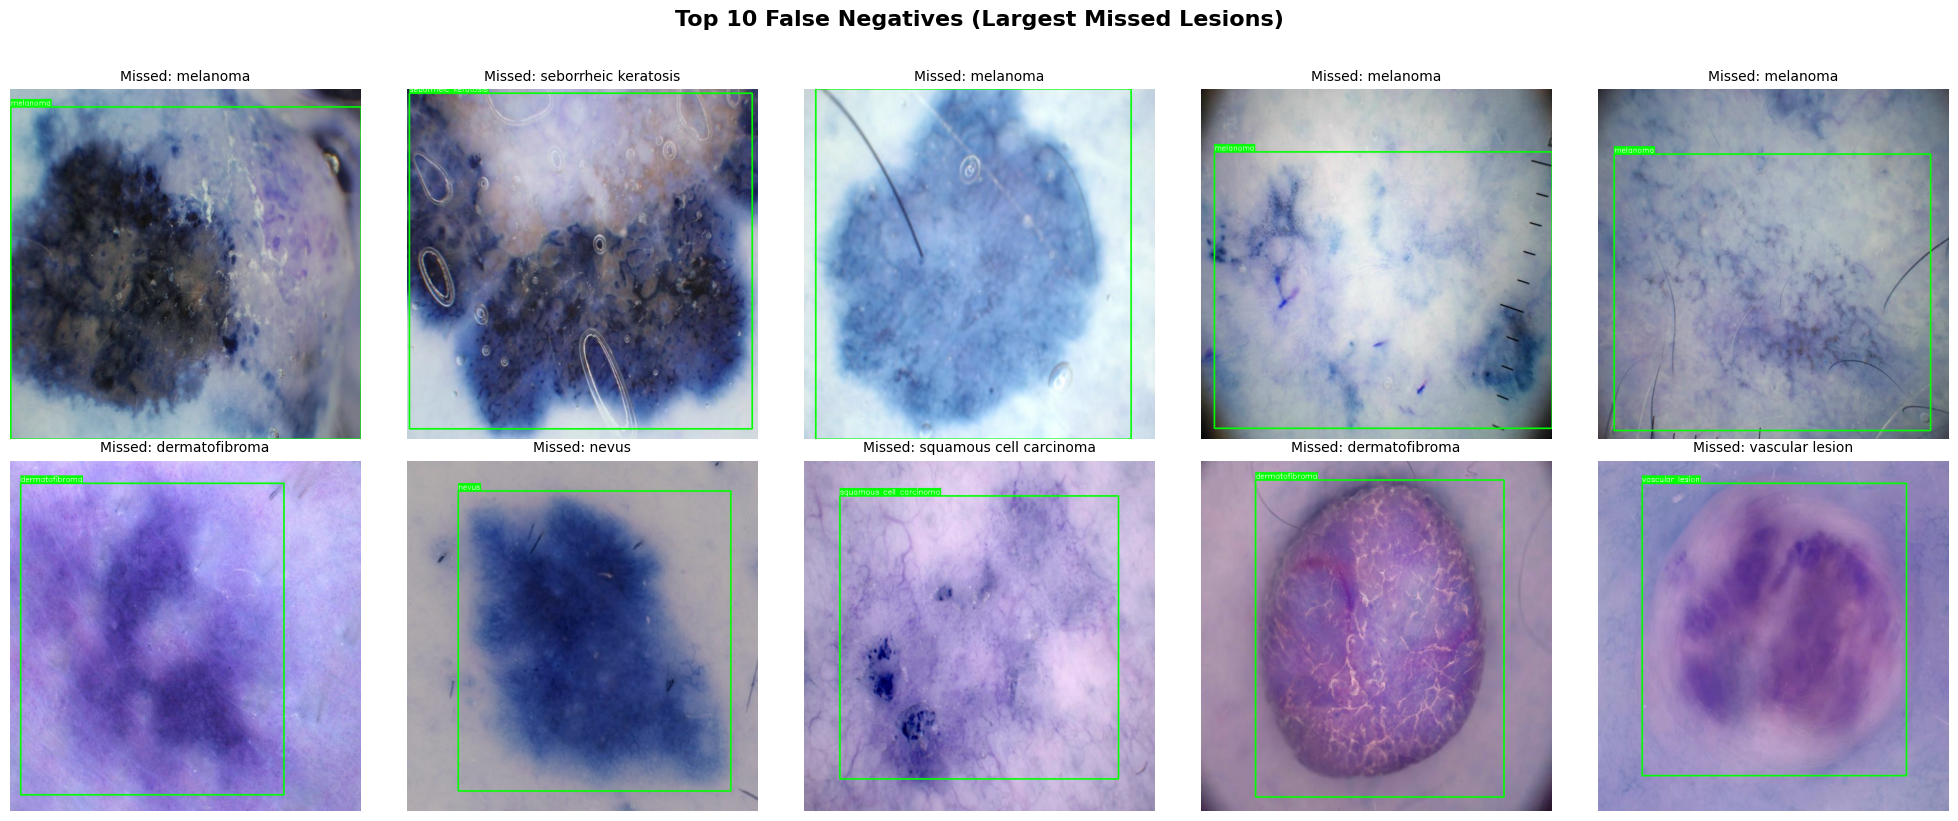

In [12]:
def get_top_cases(preds, gts, score_thresh=CONF_THRESH):
    tp_list = []
    fp_list = []
    fn_list = []
    
    for img_idx, (pred, gt) in enumerate(zip(preds, gts)):
        pb = pred['boxes'][pred['scores'] >= score_thresh]
        pl = pred['labels'][pred['scores'] >= score_thresh]
        ps = pred['scores'][pred['scores'] >= score_thresh]
        gb, gl = gt['boxes'], gt['labels']
        
        matched_gt = set()
        for b, l, s in zip(pb, pl, ps):
            best_iou = 0
            best_j = -1
            for j, (gb_j, gl_j) in enumerate(zip(gb, gl)):
                ix1 = max(b[0].item(), gb_j[0].item()); iy1 = max(b[1].item(), gb_j[1].item())
                ix2 = min(b[2].item(), gb_j[2].item()); iy2 = min(b[3].item(), gb_j[3].item())
                inter = max(0, ix2-ix1) * max(0, iy2-iy1)
                union = (b[2].item()-b[0].item())*(b[3].item()-b[1].item()) + (gb_j[2].item()-gb_j[0].item())*(gb_j[3].item()-gb_j[1].item()) - inter
                iou = inter/union if union > 0 else 0
                if iou > best_iou:
                    best_iou = iou
                    best_j = j
            
            if best_iou >= 0.5 and best_j != -1 and gl[best_j] == l:
                tp_list.append((s.item(), img_idx, b, l, gb[best_j]))
                matched_gt.add(best_j)
            else:
                fp_list.append((s.item(), img_idx, b, l))
                
        for j, (gb_j, gl_j) in enumerate(zip(gb, gl)):
            if j not in matched_gt:
                area = (gb_j[2].item()-gb_j[0].item()) * (gb_j[3].item()-gb_j[1].item())
                fn_list.append((area, img_idx, gb_j, gl_j))
                
    # Sort
    tp_list.sort(key=lambda x: x[0], reverse=True)
    fp_list.sort(key=lambda x: x[0], reverse=True)
    fn_list.sort(key=lambda x: x[0], reverse=True) # Largest missed
    
    return tp_list[:10], fp_list[:10], fn_list[:10]

top_tps, top_fps, top_fns = get_top_cases(all_preds, all_gts)

def plot_top_10(case_list, title, case_type):
    if not case_list:
        print(f"No {case_type} cases found.")
        return
    
    n_cases = len(case_list)
    rows = 2
    cols = 5
    fig, axes = plt.subplots(rows, cols, figsize=(20, 8))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        if i < n_cases:
            if case_type == 'TP':
                s, img_idx, b, l, gb = case_list[i]
                info = f"Score: {s:.2f} | Cls: {CLASSES[l-1]}"
            elif case_type == 'FP':
                s, img_idx, b, l = case_list[i]
                info = f"Score: {s:.2f} | Pred: {CLASSES[l-1]}"
            else: # FN
                area, img_idx, gb, gl = case_list[i]
                info = f"Missed: {CLASSES[gl-1]}"
            
            img_np = tensor_to_bgr(all_imgs[img_idx])
            
            if case_type == 'TP':
                img_np = draw_boxes(img_np, [gb], [l], color_map={CLASSES[l-1]: (0,255,0)})
                img_np = draw_boxes(img_np, [b], [l], [s], color_map={CLASSES[l-1]: (255,0,0)})
            elif case_type == 'FP':
                img_np = draw_boxes(img_np, [b], [l], [s], color_map={CLASSES[l-1]: (255,0,0)})
            elif case_type == 'FN':
                img_np = draw_boxes(img_np, [gb], [gl], color_map={CLASSES[gl-1]: (0,255,0)})
                
            ax.imshow(cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB))
            ax.set_title(info, fontsize=10)
            ax.axis('off')
        else:
            ax.axis('off')
            
    plt.tight_layout()
    plt.savefig(f'{case_type.lower()}_top10.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_top_10(top_tps, 'Top 10 True Positives (Most Confident Correct Detections)', 'TP')
plot_top_10(top_fps, 'Top 10 Worst False Positives (High Confidence Errors)', 'FP')
plot_top_10(top_fns, 'Top 10 False Negatives (Largest Missed Lesions)', 'FN')


In [13]:
print('╔══════════════════════════════════════════════════════╗')
print(f"║{'SKIN DISEASE DETECTION — FINAL REPORT':^54}║")
print('╠══════════════════════════════════════════════════════╣')
print(f"║  Model      : Faster R-CNN + ResNet-50 FPN{'':<12}║")
print(f"║  Test Images: {len(dataset):<3} images across 9 classes{'':<14}║")
print('╠══════════════════════════════════════════════════════╣')
print(f"║  mAP@0.50:0.95 : {map_all:.4f}{'':<33}║")
print(f"║  mAP@0.50      : {map_50:.4f}{'':<33}║")
print(f"║  mAP@0.75      : {map_75:.4f}{'':<33}║")
print(f"║  Precision     : {prec:.4f}  (conf≥{CONF_THRESH}, IoU≥0.5){'':<12}║")
print(f"║  Recall        : {rec:.4f}  (conf≥{CONF_THRESH}, IoU≥0.5){'':<12}║")
print(f"║  F1-Score      : {f1:.4f}{'':<33}║")
print('╠══════════════════════════════════════════════════════╣')
print("║  Outputs saved:                                      ║")
print("║    mAP_per_class.png  pr_curve.png  gt_vs_pred.png  ║")
print('╚══════════════════════════════════════════════════════╝')


╔══════════════════════════════════════════════════════╗
║        SKIN DISEASE DETECTION — FINAL REPORT         ║
╠══════════════════════════════════════════════════════╣
║  Model      : Faster R-CNN + ResNet-50 FPN            ║
║  Test Images: 100 images across 9 classes              ║
╠══════════════════════════════════════════════════════╣
║  mAP@0.50:0.95 : 0.0042                                 ║
║  mAP@0.50      : 0.0147                                 ║
║  mAP@0.75      : 0.0007                                 ║
║  Precision     : 0.0031  (conf≥0.3, IoU≥0.5)            ║
║  Recall        : 0.0392  (conf≥0.3, IoU≥0.5)            ║
║  F1-Score      : 0.0058                                 ║
╠══════════════════════════════════════════════════════╣
║  Outputs saved:                                      ║
║    mAP_per_class.png  pr_curve.png  gt_vs_pred.png  ║
╚══════════════════════════════════════════════════════╝
